# Combine Results

Notebook to aggregate results from different models and validation folds.

In [1]:
import pandas as pd
import numpy as np
import os
import json
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

dataset = "Tramadol-related_mortalities"
dirpath = os.path.join(r'/home/hsdslab/Documents/Csabi/Pharma_crossval/DeepCausalPV-master-main/dat',dataset,'proc')

In [2]:
def classification_scores(df, score_column, n_bins=10):
    """
    Calculates the Expected Calibration Error (ECE) of a binary classifier.
    
    Parameters:
        y_true (np.array): True binary labels (0 or 1).
        y_prob (np.array): Predicted probabilities for the positive class.
        n_bins (int): Number of bins for calibration.
        
    Returns:
        float: Expected Calibration Error (ECE) of the classifier.
    """
    y_true = df["label"].values
    y_prob = df[score_column].values
    
    # Ensure inputs are numeric
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)
    
    # Calculate bin edges and indices
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_prob, bin_edges, right=True) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)  # Clip to ensure valid indices
    
    bin_correct_sums = np.zeros(n_bins)
    bin_total_sums = np.zeros(n_bins)
    
    for i in range(n_bins):
        bin_samples = y_true[bin_indices == i]
        bin_total_sums[i] = len(bin_samples)
        bin_correct_sums[i] = bin_samples.sum()
    
    bin_accs = np.divide(bin_correct_sums, bin_total_sums, out=np.zeros_like(bin_correct_sums), where=bin_total_sums != 0)
    bin_confs = np.bincount(bin_indices, weights=y_prob, minlength=n_bins) / (np.bincount(bin_indices, minlength=n_bins) + 1e-12)
    
    ece = np.sum(np.abs(bin_confs - bin_accs) * bin_total_sums) / len(y_true)
    
    auc = roc_auc_score(y_true, y_prob)
    precision = precision_score(y_true, y_prob.round())
    recall = recall_score(y_true, y_prob.round())
    f1 = f1_score(y_true, y_prob.round())
    accuracy = accuracy_score(y_true, y_prob.round())
    
    return [auc, precision, recall, f1, accuracy, ece]

In [3]:
def get_all(crossval_idx):
    res = {}
    xgb = pd.read_csv(os.path.join(dirpath,"cross_val_xgb", f"df_res{crossval_idx[0]}{crossval_idx[1]}.csv"), index_col=0)
    xgb.drop("label", axis=1, inplace=True)
    biobert_temp = pd.read_csv(os.path.join(dirpath,"cross_val_biobert_temp", f"df_res{crossval_idx[0]}{crossval_idx[1]}.csv"), index_col=0)
    biobert_temp.drop("label", axis=1, inplace=True)
    biobert_llm = pd.read_csv(os.path.join(dirpath,"cross_val_biobert_llm", f"df_res{crossval_idx[0]}{crossval_idx[1]}.csv"), index_col=0)
    biobert_llm.drop("label", axis=1, inplace=True)
    albert_temp = pd.read_csv(os.path.join(dirpath,"cross_val_albert_temp", f"df_res{crossval_idx[0]}{crossval_idx[1]}.csv"), index_col=0)
    albert_temp.drop("label", axis=1, inplace=True)

    df = pd.read_csv(os.path.join(dirpath,'df_together.csv'), index_col=0)
    df.drop("Temp_sentence", axis=1, inplace=True)
    df = df.loc[xgb.index]

    df = pd.concat([df, xgb, biobert_temp, biobert_llm, albert_temp], axis=1)
    
    model_names = ["xgb", "xgb_cal", "biobert_temp", "biobert_temp_cal", "biobert_llm", "biobert_llm_cal", "albert_temp", "albert_temp_cal"]
    
    for model in model_names:
        res[model] = classification_scores(df, model)
        
    return res

In [4]:
all_results = {}

for i in range(5):
    for j in range(5):
        if i!=j:
            all_results[f"{i}{j}"] = get_all((i,j))
            
with open(os.path.join(dirpath, "all_results.json"), "w") as f:
    json.dump(all_results, f)

In [5]:
metrics = {
    "auc": 0,
    "precision": 1,
    "recall": 2,
    "f1": 3,
    "accuracy": 4,
    "ece": 5
}

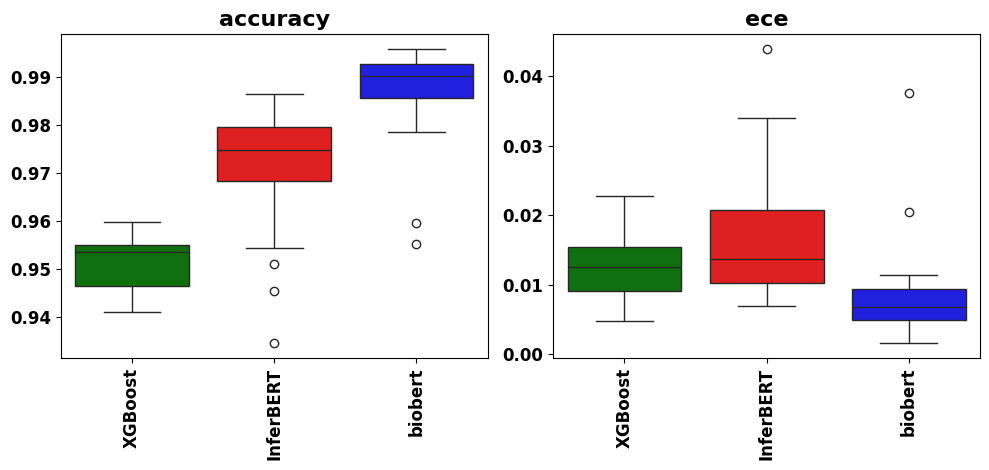

In [9]:
def plot_results2(index):    
    xgb_acc = []
    xgbcal_acc = []
    albert_acc = []
    albertcal_acc = []
    biobert_acc = []

    for key in all_results.keys():
        xgb_acc.append(all_results[key]["xgb"][index])
        xgbcal_acc.append(all_results[key]["xgb_cal"][index])
        albert_acc.append(all_results[key]["albert_temp"][index])
        albertcal_acc.append(all_results[key]["albert_temp_cal"][index])
        biobert_acc.append(all_results[key]["biobert_temp"][index])

    df_acc = pd.DataFrame({"XGBoost": xgb_acc,
                          "InferBERT": albert_acc, "biobert": biobert_acc})

    

    # Create boxplot with specified colors
    ax = sns.boxplot(data=df_acc, 
                    palette=['green', 'red', 'blue'])

    # set fonts to 12 and bold
    plt.xticks(rotation=90, fontsize=12, color='black', fontweight='bold')
    plt.yticks(fontsize=12, color='black', fontweight='bold')

    return ax
metrics = {
    "accuracy": 4,
    "ece": 5
}
# Plot all metrics with 2*3 subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 4.8))
for i, (metric, idx) in enumerate(metrics.items()):
    plt.subplot(1, 2, i+1)
    plot_results2(idx)
    plt.title(metric, fontsize=16, color='black', fontweight="bold")  # White title text

# Customize overall figure
#plt.suptitle(f"Classification metrics for {dataset} on cross-validation", 
 #           fontsize=20, color='white', fontweight="bold")  # Set background to black for better contrast with white elements
plt.tight_layout()
# save with transparent background
plt.savefig(os.path.join(dirpath, "classification_metrics2.png"))
plt.show()

/tmp/ipykernel_339578/232876132.py:27: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.boxplot(data=df_acc,
/tmp/ipykernel_339578/232876132.py:27: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.boxplot(data=df_acc,
/tmp/ipykernel_339578/232876132.py:27: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.boxplot(data=df_acc,
/tmp/ipykernel_339578/232876132.py:27: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.boxplot(data=df_acc,
/tmp/ipykernel_339578/232876132.py:27: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.boxplot(data=df_acc,
/tmp/ipykernel_339578/232876132.py:27: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  ax = sns.boxplot(data=df_acc,


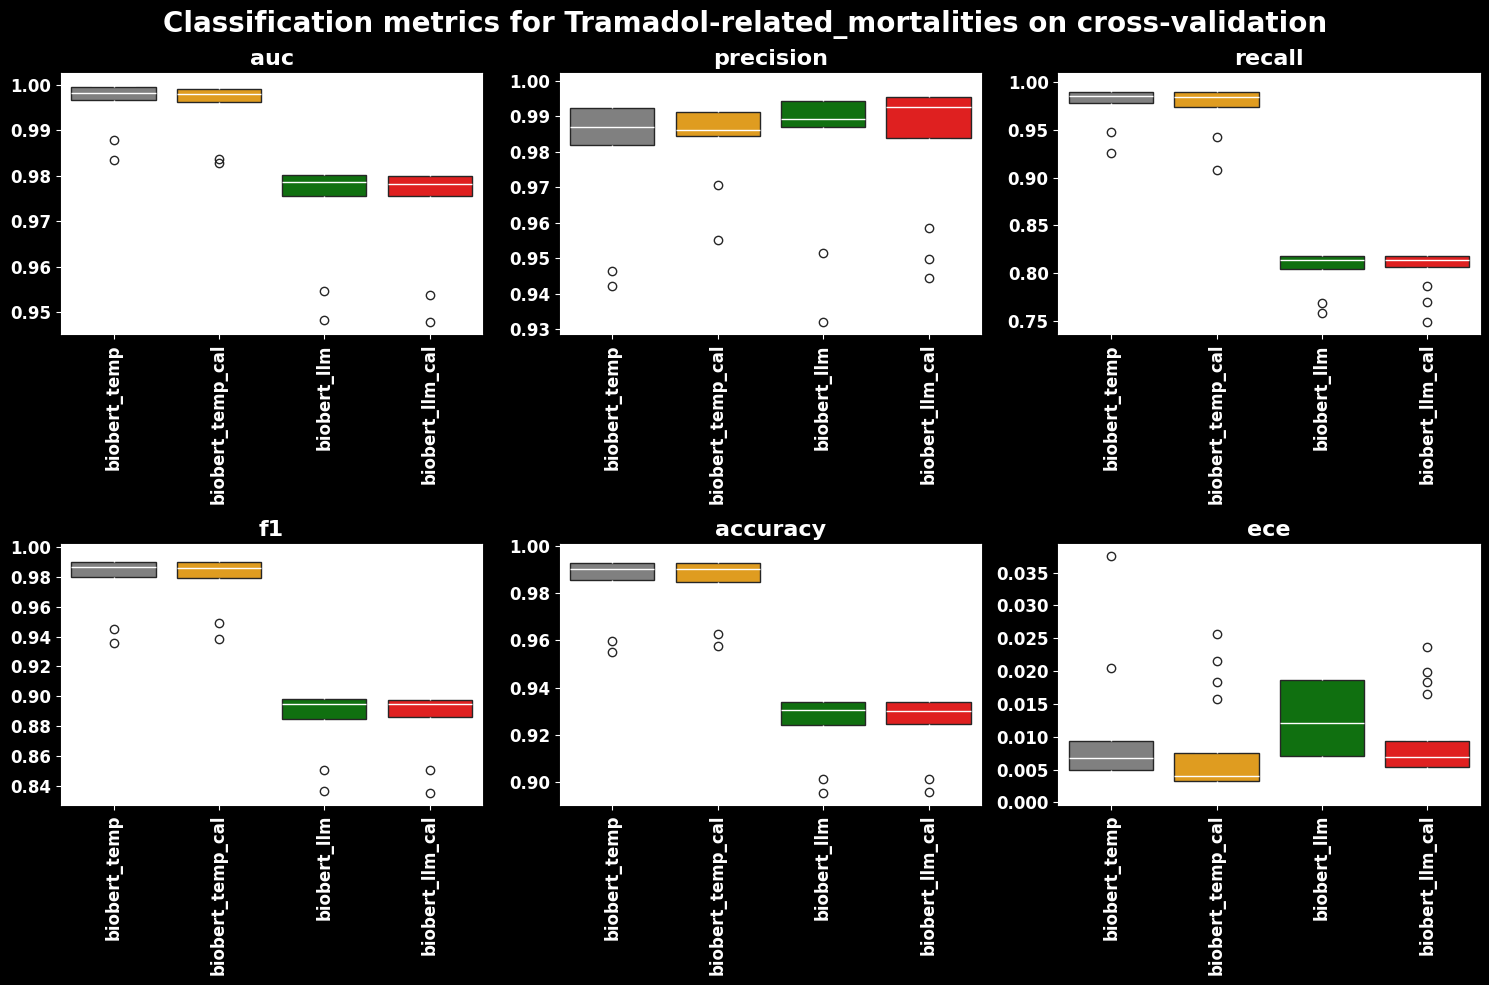

In [14]:
def plot_results(index):    
    xgb_acc = []
    xgbcal_acc = []
    biobert_acc = []
    biobertcal_acc = []
    biobertllm_acc = []
    biobertllmcal_acc = []
    albert_acc = []
    albertcal_acc = []

    for key in all_results.keys():
        xgb_acc.append(all_results[key]["xgb"][index])
        xgbcal_acc.append(all_results[key]["xgb_cal"][index])
        biobert_acc.append(all_results[key]["biobert_temp"][index])
        biobertcal_acc.append(all_results[key]["biobert_temp_cal"][index])
        biobertllm_acc.append(all_results[key]["biobert_llm"][index])
        biobertllmcal_acc.append(all_results[key]["biobert_llm_cal"][index])
        albert_acc.append(all_results[key]["albert_temp"][index])
        albertcal_acc.append(all_results[key]["albert_temp_cal"][index])

    df_acc = pd.DataFrame({"biobert_temp": biobert_acc, "biobert_temp_cal": biobertcal_acc, "biobert_llm": biobertllm_acc, "biobert_llm_cal": biobertllmcal_acc})

    # plot them as boxplots with sns



    ax = sns.boxplot(data=df_acc,
                palette = ['gray', 'orange', 'green', 'red', "purple", "brown", "pink", "yellow"])

    # Set box boundaries to white
    for box in ax.artists:
        box.set_edgecolor('white')
        box.set_linewidth(1.5)  # Optional: makes the white edges more visible
    
    # Customize whiskers, caps, and medians to white
    for line in ax.lines:
        line.set_color('white')
    
    # Customize axis appearance
    ax.spines['bottom'].set_color('white')
    ax.spines['top'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['right'].set_color('white')
    
    # Customize tick colors and labels
    ax.tick_params(colors='white')
    # set fonts to 12 and bold
    plt.xticks(rotation=90, fontsize=12, color='white', fontweight='bold')
    plt.yticks(fontsize=12, color='white', fontweight='bold')

    return ax

# Plot all metrics with 2*3 subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for i, (metric, idx) in enumerate(metrics.items()):
    plt.subplot(2, 3, i+1)
    plot_results(idx)
    plt.title(metric, fontsize=16, color='white', fontweight="bold")  # White title text

# Customize overall figure
plt.suptitle(f"Classification metrics for {dataset} on cross-validation", 
            fontsize=20, color='white', fontweight="bold")
fig.set_facecolor('black')  # Set background to black for better contrast with white elements
plt.tight_layout()
# save with transparent background
plt.savefig(os.path.join(dirpath, "classification_metrics_all_tram.png"), transparent=True)
plt.show()


In [11]:
def plot_results2(index):    
    xgb_acc = []
    xgbcal_acc = []
    biobert_acc = []
    biobertcal_acc = []
    biobertllm_acc = []
    biobertllmcal_acc = []
    albert_acc = []
    albertcal_acc = []

    for key in all_results.keys():
        xgb_acc.append(all_results[key]["xgb"][index])
        xgbcal_acc.append(all_results[key]["xgb_cal"][index])
        biobert_acc.append(all_results[key]["biobert_temp"][index])
        biobertcal_acc.append(all_results[key]["biobert_temp_cal"][index])
        biobertllm_acc.append(all_results[key]["biobert_llm"][index])
        biobertllmcal_acc.append(all_results[key]["biobert_llm_cal"][index])
        albert_acc.append(all_results[key]["albert_temp"][index])
        albertcal_acc.append(all_results[key]["albert_temp_cal"][index])

    df_acc = pd.DataFrame({"biobert_temp": biobert_acc, "biobert_temp_cal": biobertcal_acc, "biobert_llm": biobertllm_acc, "biobert_llm_cal": biobertllmcal_acc})


    # plot them as boxplots with sns

    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.boxplot(data=df_acc)
    # rotate x-axis labels
    plt.xticks(rotation=90)

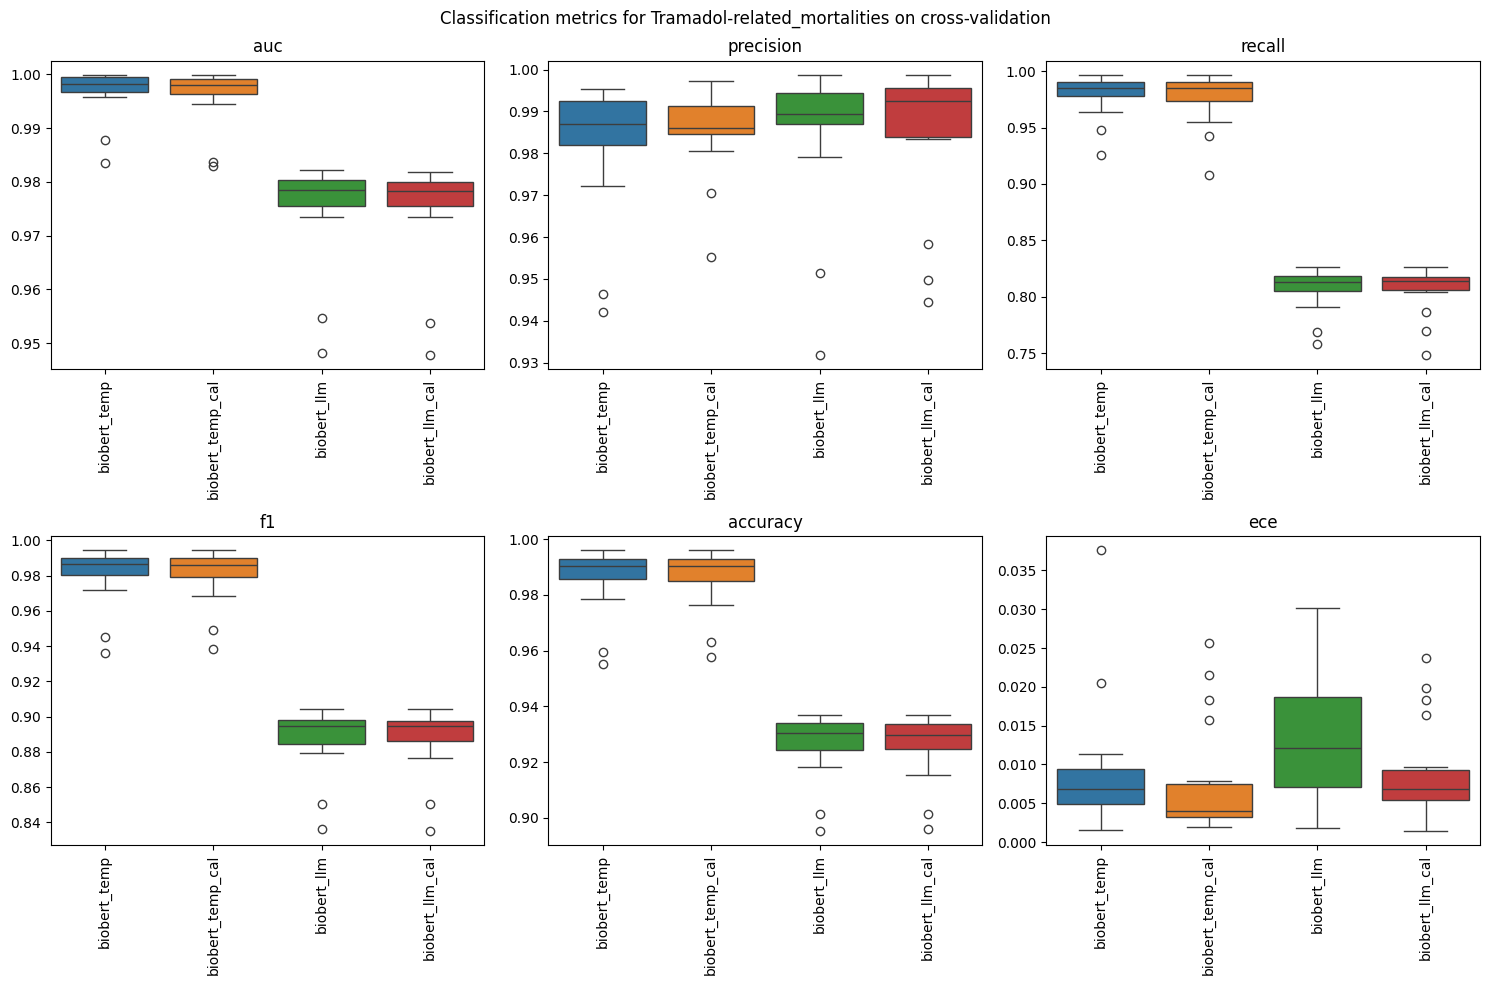

In [12]:
import matplotlib.pyplot as plt
# plot all metrics with 2*3 subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for i, (metric, idx) in enumerate(metrics.items()):
    plt.subplot(2, 3, i+1)
    plot_results2(idx)
    plt.title(metric)

plt.suptitle(f"Classification metrics for {dataset} on cross-validation")
plt.tight_layout()
plt.show()

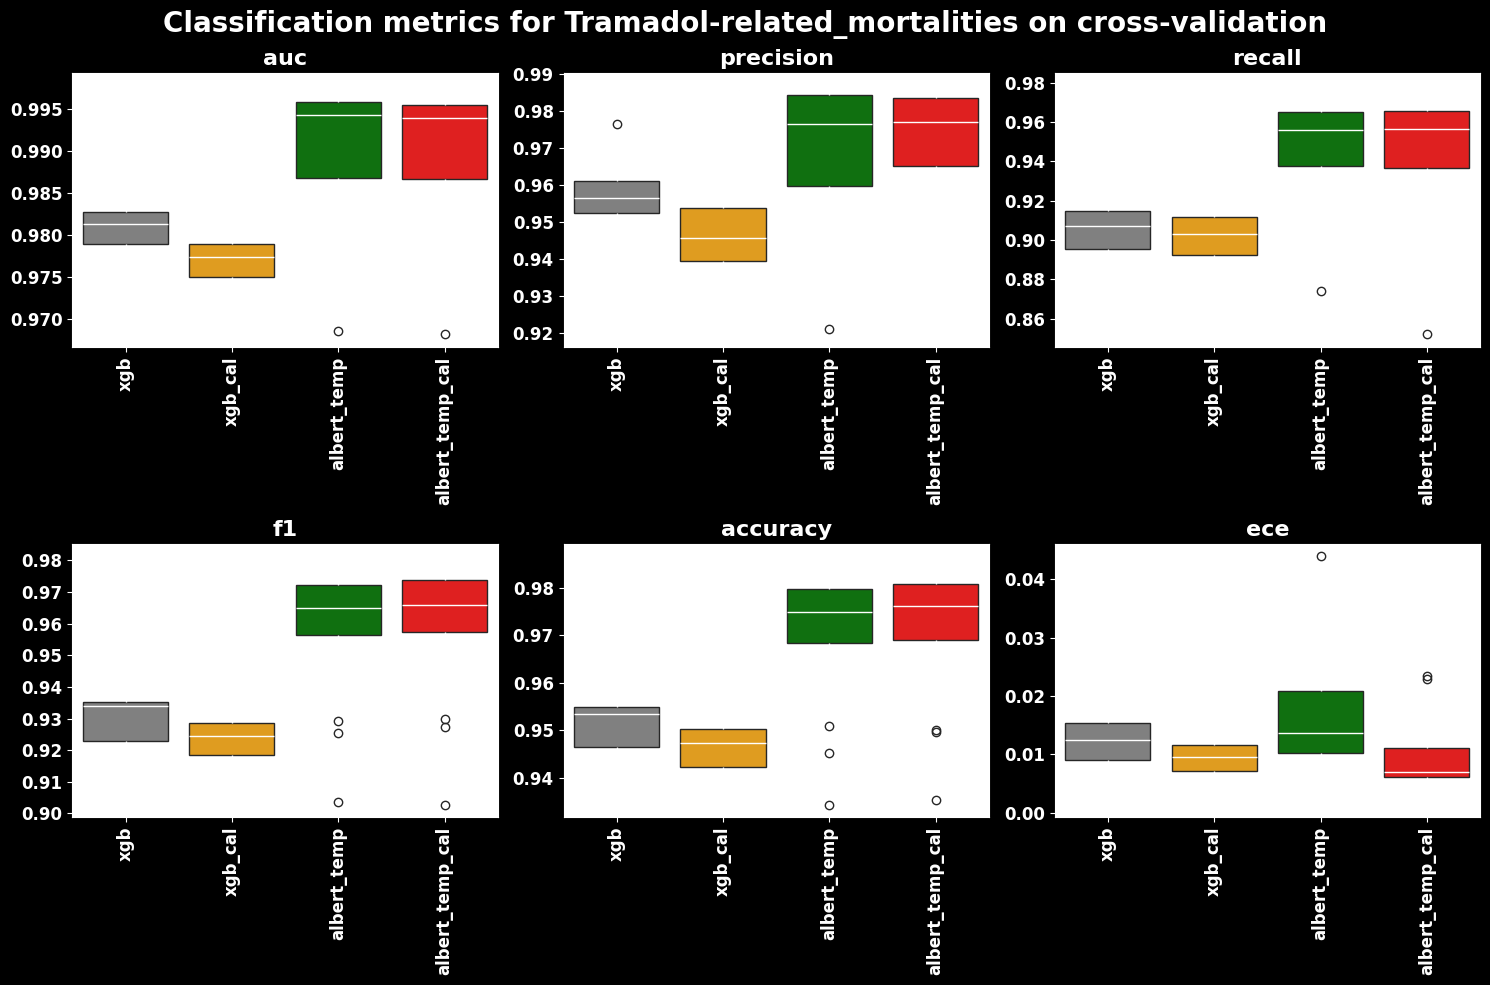

In [10]:
def plot_results2(index):    
    xgb_acc = []
    xgbcal_acc = []
    albert_acc = []
    albertcal_acc = []

    for key in all_results.keys():
        xgb_acc.append(all_results[key]["xgb"][index])
        xgbcal_acc.append(all_results[key]["xgb_cal"][index])
        albert_acc.append(all_results[key]["albert_temp"][index])
        albertcal_acc.append(all_results[key]["albert_temp_cal"][index])

    df_acc = pd.DataFrame({"xgb": xgb_acc, "xgb_cal": xgbcal_acc, 
                          "albert_temp": albert_acc, "albert_temp_cal": albertcal_acc})

    

    # Create boxplot with specified colors
    ax = sns.boxplot(data=df_acc, 
                    palette=['gray', 'orange', 'green', 'red'])
    
    # Set box boundaries to white
    for box in ax.artists:
        box.set_edgecolor('white')
        box.set_linewidth(1.5)  # Optional: makes the white edges more visible
    
    # Customize whiskers, caps, and medians to white
    for line in ax.lines:
        line.set_color('white')
    
    # Customize axis appearance
    ax.spines['bottom'].set_color('white')
    ax.spines['top'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['right'].set_color('white')
    
    # Customize tick colors and labels
    ax.tick_params(colors='white')
    # set fonts to 12 and bold
    plt.xticks(rotation=90, fontsize=12, color='white', fontweight='bold')
    plt.yticks(fontsize=12, color='white', fontweight='bold')

    return ax

# Plot all metrics with 2*3 subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for i, (metric, idx) in enumerate(metrics.items()):
    plt.subplot(2, 3, i+1)
    plot_results2(idx)
    plt.title(metric, fontsize=16, color='white', fontweight="bold")  # White title text

# Customize overall figure
plt.suptitle(f"Classification metrics for {dataset} on cross-validation", 
            fontsize=20, color='white', fontweight="bold")
fig.set_facecolor('black')  # Set background to black for better contrast with white elements
plt.tight_layout()
# save with transparent background
plt.savefig(os.path.join(dirpath, "classification_metrics.png"), transparent=True)
plt.show()